# H-1B LCA Analysis 
---

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})

FILE_PATH  = r'D:\shivs2\pythonproject\practicesheet\class1\final_dataset.csv'   # <-- UPDATE THIS
OUTPUT_DIR = 'h1b_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Setup complete ✓')

Setup complete ✓


## Phase 1 — Data Understanding

In [14]:
df   = pd.read_csv(FILE_PATH, low_memory=False)
h1b  = df[df['VISA_CLASS'].str.upper().str.contains('H-1B', na=False)].copy()

print(f'Total rows  : {len(df):,}')
print(f'H-1B rows   : {len(h1b):,}')
print(f'Columns     : {len(df.columns)}')
h1b.head(3)

Total rows  : 596,552
H-1B rows   : 586,155
Columns     : 99


,CASE_NUMBER,CASE_STATUS,RECEIVED_DATE,DECISION_DATE,ORIGINAL_CERT_DATE,VISA_CLASS,JOB_TITLE,SOC_CODE,SOC_TITLE,FULL_TIME_POSITION,...,STATUTORY_BASIS,APPENDIX_A_ATTACHED,PUBLIC_DISCLOSURE,PREPARER_LAST_NAME,PREPARER_FIRST_NAME,PREPARER_MIDDLE_INITIAL,PREPARER_BUSINESS_NAME,PREPARER_EMAIL,LAWFIRM_BUSINESS_FEIN,H_1B_DEPENDENT
0,I-200-24366-578757,Withdrawn,2024-12-31,2024-12-31,NaN,H-1B,Database Administrator,15-1242.00,Database Administrators,N,...,"Both $60,000 or higher in annual wage and Mast...",NaN,Disclose Business,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,I-200-24366-578499,Withdrawn,2024-12-31,2024-12-31,NaN,H-1B,Abdominal Radiologist Assistant Professor Clin...,29-1224.00,Radiologists,Y,...,NaN,NaN,Disclose Business,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,I-200-24366-578081,Withdrawn,2024-12-31,2024-12-31,NaN,H-1B,PROJECT MANAGER,15-1299.09,Information Technology Project Managers,Y,...,"$60,000 or higher annual wage",NaN,Disclose Business,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
# Column types
print('Categorical columns:', ['CASE_STATUS','VISA_CLASS','FULL_TIME_POSITION','WAGE_UNIT_OF_PAY','PW_UNIT_OF_PAY','PW_WAGE_LEVEL','WORKSITE_STATE'])
print('Numeric columns    :', ['WAGE_RATE_OF_PAY_FROM','WAGE_RATE_OF_PAY_TO','PREVAILING_WAGE','TOTAL_WORKER_POSITIONS'])
print('Date columns       :', ['RECEIVED_DATE','DECISION_DATE','BEGIN_DATE','END_DATE'])
print('Binary (Y/N)       :', ['H-1B_DEPENDENT','WILLFUL_VIOLATOR','SUPPORT_H1B','FULL_TIME_POSITION'])

# Missing values
print('\nTop missing columns:')
h1b.isnull().mean().sort_values(ascending=False).head(10).mul(100).round(1)

Categorical columns: ['CASE_STATUS', 'VISA_CLASS', 'FULL_TIME_POSITION', 'WAGE_UNIT_OF_PAY', 'PW_UNIT_OF_PAY', 'PW_WAGE_LEVEL', 'WORKSITE_STATE']
Numeric columns    : ['WAGE_RATE_OF_PAY_FROM', 'WAGE_RATE_OF_PAY_TO', 'PREVAILING_WAGE', 'TOTAL_WORKER_POSITIONS']
Date columns       : ['RECEIVED_DATE', 'DECISION_DATE', 'BEGIN_DATE', 'END_DATE']
Binary (Y/N)       : ['H-1B_DEPENDENT', 'WILLFUL_VIOLATOR', 'SUPPORT_H1B', 'FULL_TIME_POSITION']

Top missing columns:


APPENDIX_A_ATTACHED         99.9
PW_TRACKING_NUMBER          99.9
EMPLOYER_POC_PROVINCE       98.9
AGENT_ATTORNEY_PHONE_EXT    96.2
EMPLOYER_PROVINCE           95.1
EMPLOYER_POC_PHONE_EXT      95.0
ORIGINAL_CERT_DATE          94.8
EMPLOYER_PHONE_EXT          94.6
PW_SURVEY_NAME              93.9
PW_SURVEY_PUBLISHER         93.9
dtype: float64

In [16]:
# Parse dates
for c in ['RECEIVED_DATE','DECISION_DATE','BEGIN_DATE','END_DATE']:
    if c in h1b.columns:
        h1b[c] = pd.to_datetime(h1b[c], errors='coerce')

# Wage normalisation to annual
def to_annual(row, wage_col, unit_col):
    try:
        w = float(row[wage_col])
        u = str(row[unit_col]).upper()
        if 'HOUR'  in u: return w * 2080
        if 'WEEK'  in u: return w * 52
        if 'BI'    in u: return w * 26
        if 'MONTH' in u: return w * 12
        return w
    except: return np.nan

h1b['ANNUAL_WAGE'] = h1b.apply(lambda r: to_annual(r,'WAGE_RATE_OF_PAY_FROM','WAGE_UNIT_OF_PAY'), axis=1)
h1b['PW_ANNUAL']   = h1b.apply(lambda r: to_annual(r,'PREVAILING_WAGE','PW_UNIT_OF_PAY'), axis=1)
h1b['WAGE_RATIO']  = h1b['ANNUAL_WAGE'] / h1b['PW_ANNUAL']
h1b['IS_CERTIFIED']= h1b['CASE_STATUS'].str.upper().str.contains('CERTIFIED', na=False) & \
                     ~h1b['CASE_STATUS'].str.upper().str.contains('WITHDRAWN', na=False)

print('Derived columns added ✓')
print('Case status distribution:')
h1b['CASE_STATUS'].value_counts()

Derived columns added ✓
Case status distribution:


CASE_STATUS
Certified                542879
Certified - Withdrawn     30387
Withdrawn                  9288
Denied                     3601
Name: count, dtype: int64

## Phase 2 — Descriptive Analysis

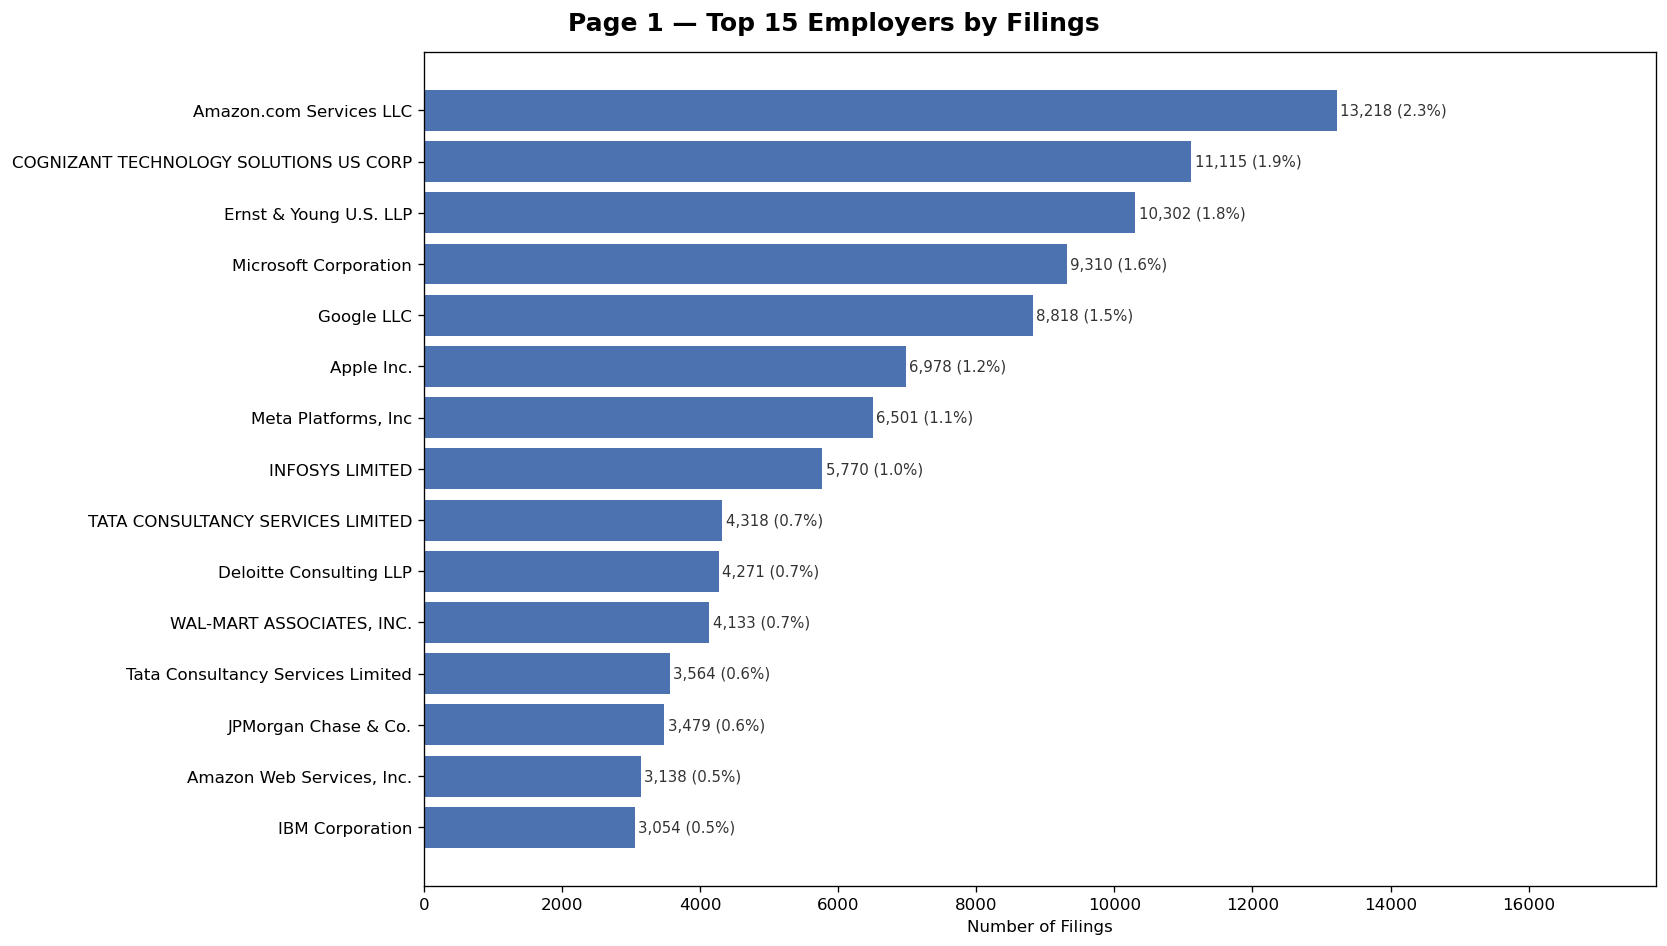

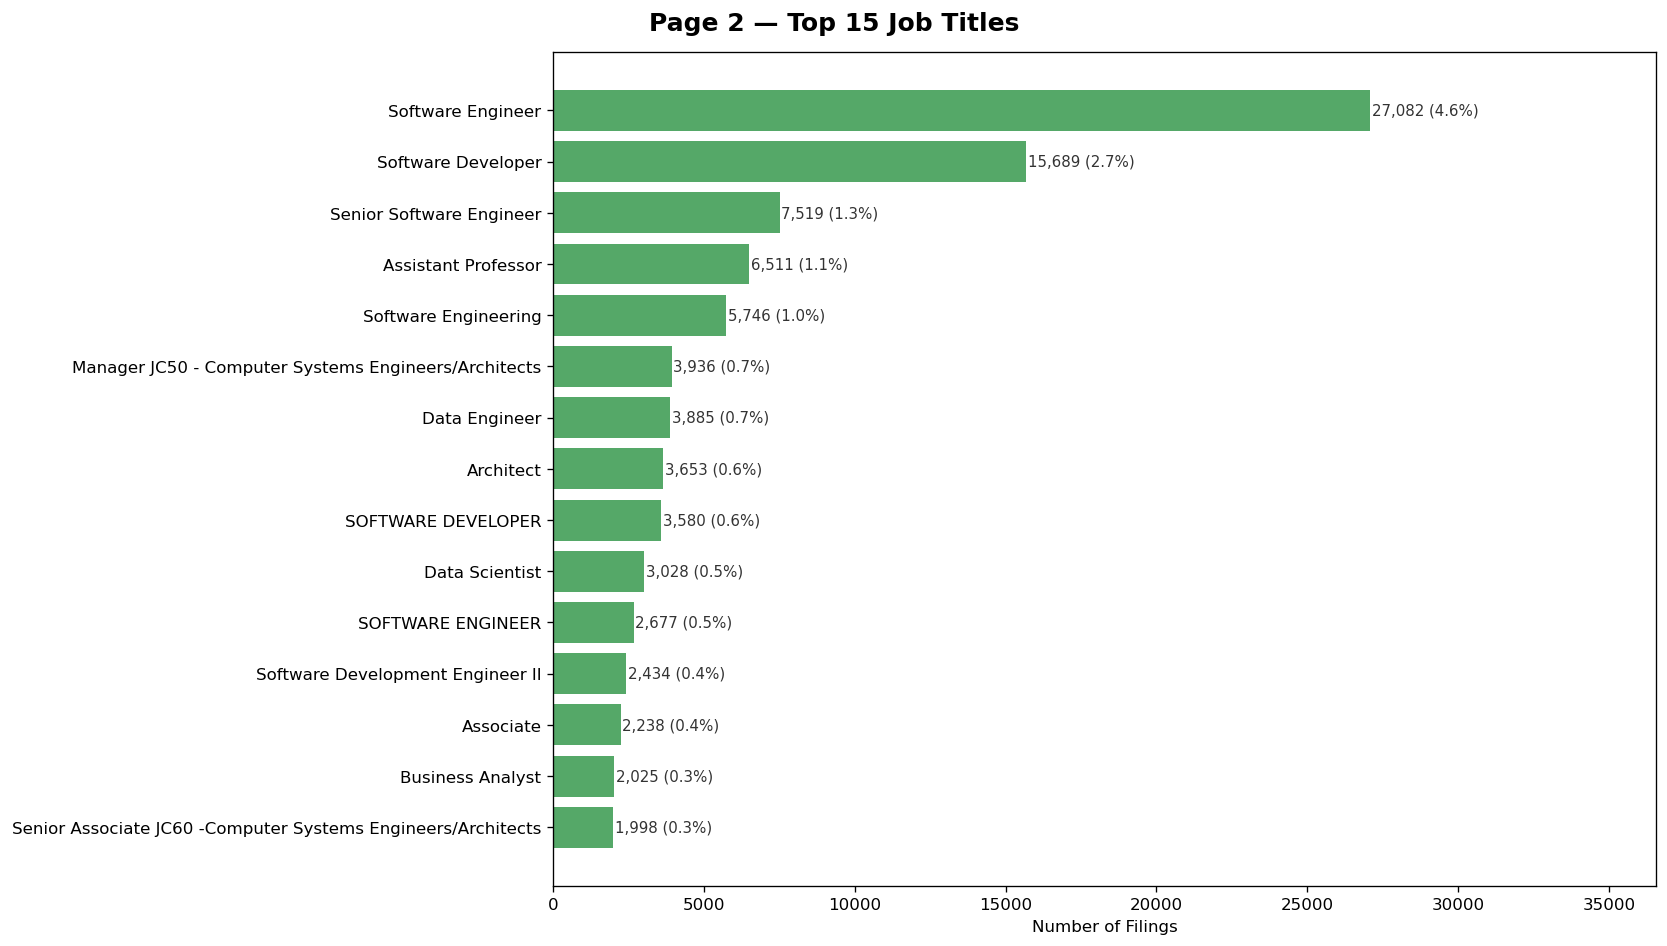

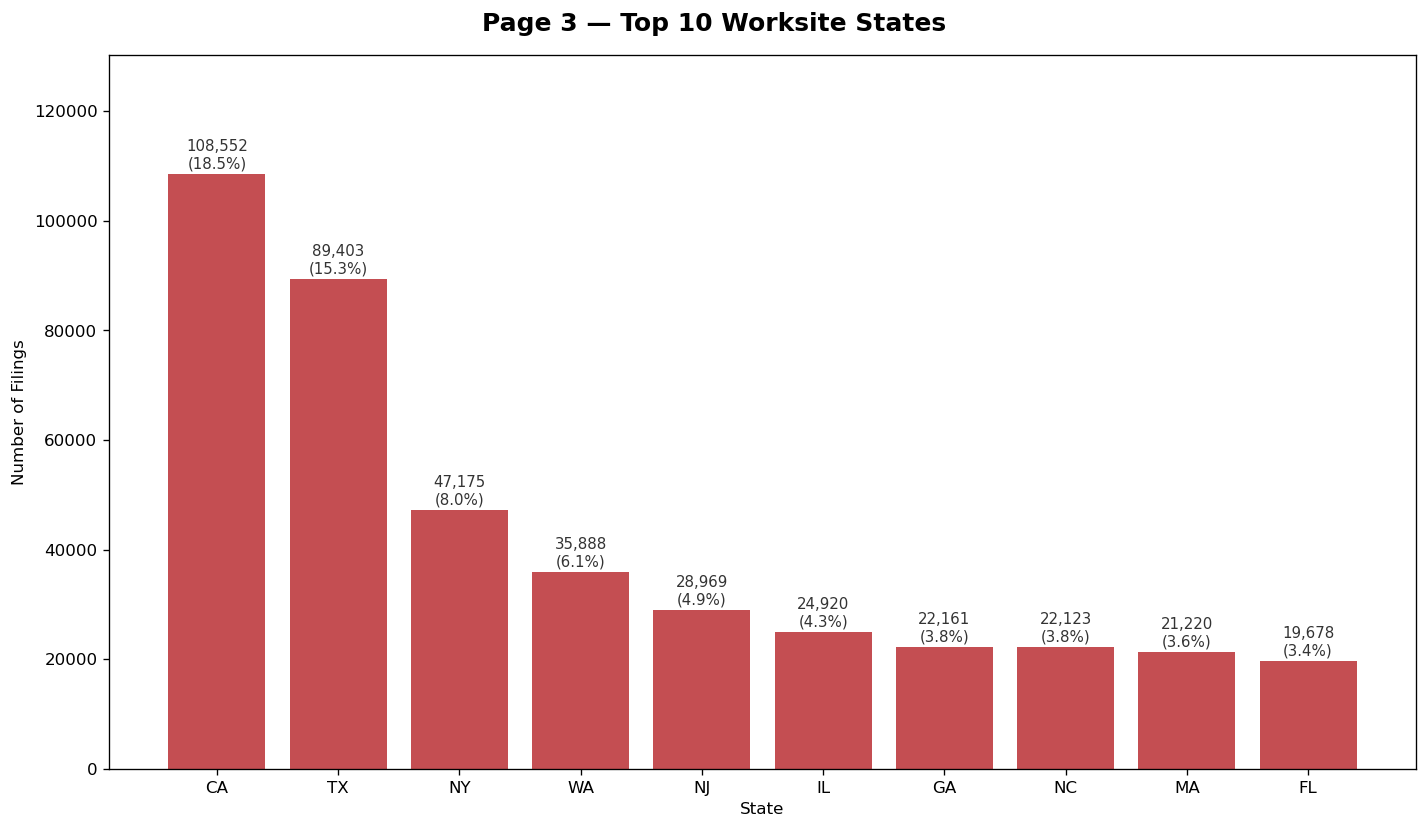

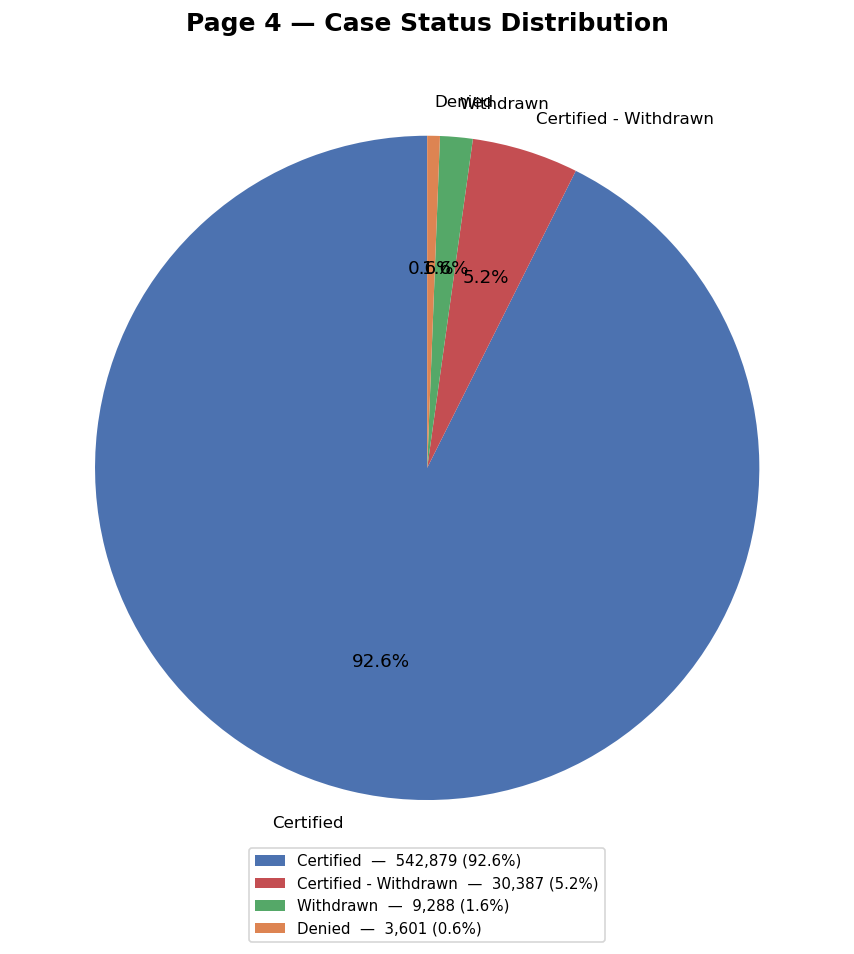


Overall Certification Rate: 92.6%

All 4 charts saved to → h1b_outputs/


In [21]:
import matplotlib.gridspec as gridspec

total = len(h1b)

top_emp    = h1b['EMPLOYER_NAME'].value_counts().head(15)
top_jobs   = h1b['JOB_TITLE'].value_counts().head(15)
top_states = h1b['WORKSITE_STATE'].value_counts().head(10)
cert_counts = h1b['CASE_STATUS'].value_counts().head(4)

# ── PAGE 1 — Top 15 Employers ─────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(14, 8))
fig1.suptitle('Page 1 — Top 15 Employers by Filings', fontsize=15, fontweight='bold')

ax1.barh(top_emp.index[::-1], top_emp.values[::-1], color='#4C72B0')
for i, v in enumerate(top_emp.values[::-1]):
    ax1.text(v + 50, i, f'{v:,} ({v/total*100:.1f}%)',
             va='center', fontsize=9, color='#333333')
ax1.set_xlim(0, top_emp.max() * 1.35)
ax1.set_xlabel('Number of Filings')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/page1_employers.png', bbox_inches='tight')
plt.show()

# ── PAGE 2 — Top 15 Job Titles ────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(14, 8))
fig2.suptitle('Page 2 — Top 15 Job Titles', fontsize=15, fontweight='bold')

ax2.barh(top_jobs.index[::-1], top_jobs.values[::-1], color='#55A868')
for i, v in enumerate(top_jobs.values[::-1]):
    ax2.text(v + 50, i, f'{v:,} ({v/total*100:.1f}%)',
             va='center', fontsize=9, color='#333333')
ax2.set_xlim(0, top_jobs.max() * 1.35)
ax2.set_xlabel('Number of Filings')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/page2_job_titles.png', bbox_inches='tight')
plt.show()

# ── PAGE 3 — Top 10 Worksite States ──────────────────────────
fig3, ax3 = plt.subplots(figsize=(12, 7))
fig3.suptitle('Page 3 — Top 10 Worksite States', fontsize=15, fontweight='bold')

ax3.bar(top_states.index, top_states.values, color='#C44E52')
for i, v in enumerate(top_states.values):
    ax3.text(i, v + top_states.max() * 0.01,
             f'{v:,}\n({v/total*100:.1f}%)',
             ha='center', fontsize=9, color='#333333')
ax3.set_ylim(0, top_states.max() * 1.2)
ax3.set_xlabel('State')
ax3.set_ylabel('Number of Filings')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/page3_worksite_states.png', bbox_inches='tight')
plt.show()

# ── PAGE 4 — Case Status Distribution (Pie) ───────────────────
fig4, ax4 = plt.subplots(figsize=(10, 8))
fig4.suptitle('Page 4 — Case Status Distribution', fontsize=15, fontweight='bold')

wedges, texts, autotexts = ax4.pie(
    cert_counts.values,
    labels=cert_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4C72B0', '#C44E52', '#55A868', '#DD8452']
)
for text in autotexts:
    text.set_fontsize(11)

# add count labels in legend
legend_labels = [f'{l}  —  {v:,} ({v/total*100:.1f}%)'
                 for l, v in zip(cert_counts.index, cert_counts.values)]
ax4.legend(wedges, legend_labels, loc='lower center',
           bbox_to_anchor=(0.5, -0.08), fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/page4_case_status.png', bbox_inches='tight')
plt.show()

overall_cert = h1b['IS_CERTIFIED'].mean() * 100
print(f'\nOverall Certification Rate: {overall_cert:.1f}%')
print(f'\nAll 4 charts saved to → {OUTPUT_DIR}/')

## Phase 3 — Diagnostic Analysis

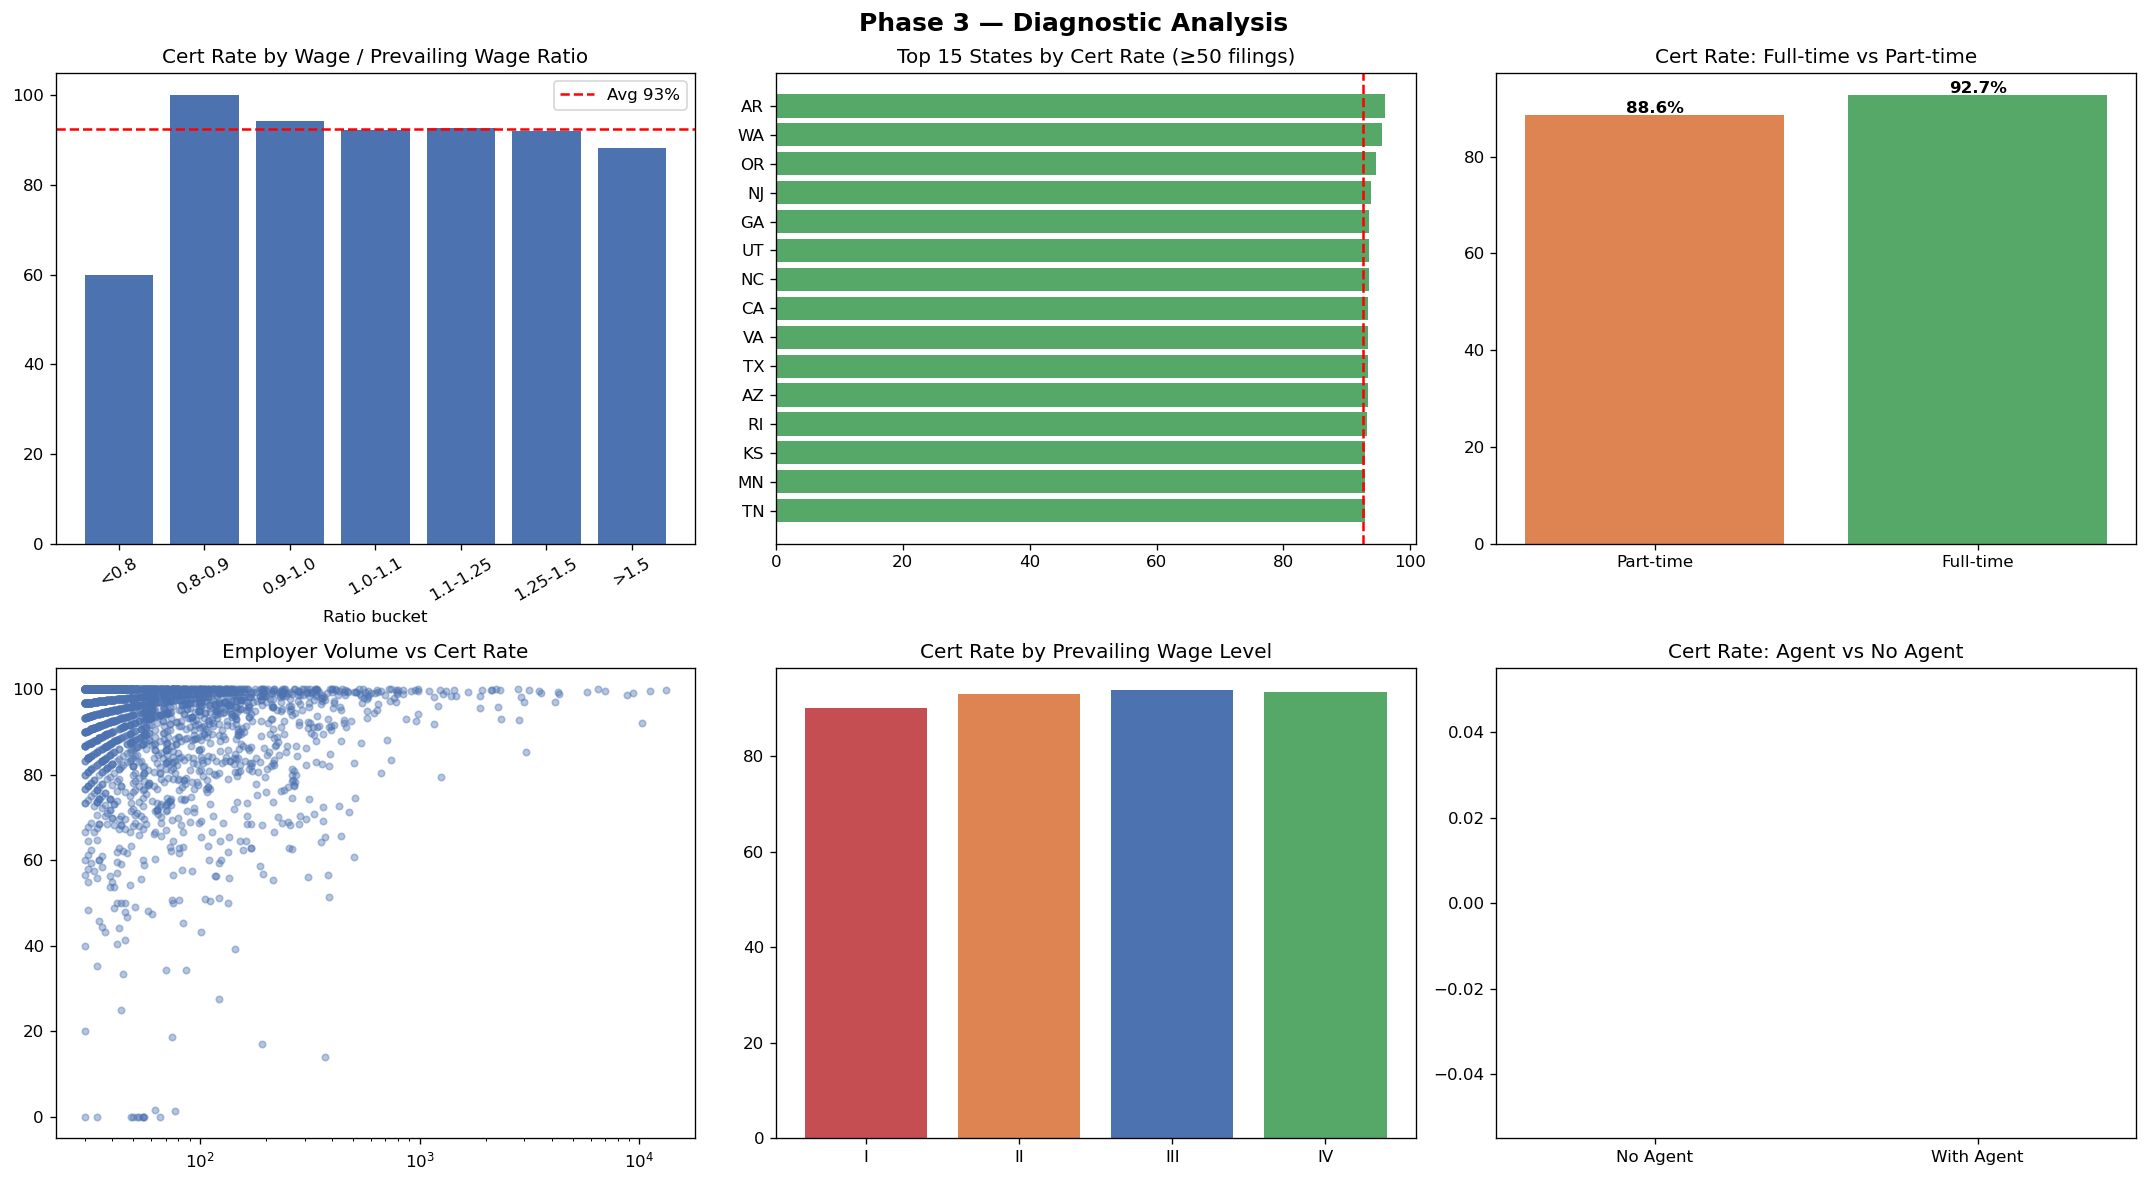

In [22]:
h1b['WAGE_RATIO_BIN'] = pd.cut(
    h1b['WAGE_RATIO'].clip(0.5, 2.5),
    bins=[0.5,0.8,0.9,1.0,1.1,1.25,1.5,2.5],
    labels=['<0.8','0.8-0.9','0.9-1.0','1.0-1.1','1.1-1.25','1.25-1.5','>1.5']
)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Phase 3 — Diagnostic Analysis', fontsize=15, fontweight='bold')

# Does wage matter?
wage_cert = h1b.groupby('WAGE_RATIO_BIN', observed=True)['IS_CERTIFIED'].mean()*100
axes[0,0].bar(wage_cert.index, wage_cert.values, color='#4C72B0')
axes[0,0].axhline(overall_cert, color='red', linestyle='--', label=f'Avg {overall_cert:.0f}%')
axes[0,0].set_title('Cert Rate by Wage / Prevailing Wage Ratio')
axes[0,0].set_xlabel('Ratio bucket'); axes[0,0].tick_params(axis='x', rotation=30)
axes[0,0].legend()

# Does state matter?
state_cert = (h1b.groupby('WORKSITE_STATE')
                 .agg(cert_rate=('IS_CERTIFIED','mean'), count=('IS_CERTIFIED','count'))
                 .query('count >= 50').nlargest(15,'cert_rate'))
axes[0,1].barh(state_cert.index[::-1], (state_cert['cert_rate']*100)[::-1], color='#55A868')
axes[0,1].axvline(overall_cert, color='red', linestyle='--')
axes[0,1].set_title('Top 15 States by Cert Rate (≥50 filings)')

# Full-time vs Part-time
ft_cert = h1b.groupby('FULL_TIME_POSITION')['IS_CERTIFIED'].mean()*100
vals = ft_cert.reindex(['N','Y']).fillna(0).values
axes[0,2].bar(['Part-time','Full-time'], vals, color=['#DD8452','#55A868'])
axes[0,2].set_title('Cert Rate: Full-time vs Part-time')
for i,v in enumerate(vals): axes[0,2].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Employer scatter
emp_d = (h1b.groupby('EMPLOYER_NAME')
            .agg(cert=('IS_CERTIFIED','mean'), vol=('IS_CERTIFIED','count'))
            .query('vol >= 30').reset_index())
axes[1,0].scatter(emp_d['vol'], emp_d['cert']*100, alpha=0.4, s=15, color='#4C72B0')
axes[1,0].set_xscale('log'); axes[1,0].set_title('Employer Volume vs Cert Rate')

# PW level
if 'PW_WAGE_LEVEL' in h1b.columns:
    pw_cert = h1b[h1b['PW_WAGE_LEVEL'].isin(['I','II','III','IV'])].groupby('PW_WAGE_LEVEL')['IS_CERTIFIED'].mean()*100
    axes[1,1].bar(['I','II','III','IV'], pw_cert.reindex(['I','II','III','IV']).values,
                  color=['#C44E52','#DD8452','#4C72B0','#55A868'])
    axes[1,1].set_title('Cert Rate by Prevailing Wage Level')

# Agent
if 'AGENT_REPRESENTING_EMPLOYER' in h1b.columns:
    ag = h1b.groupby('AGENT_REPRESENTING_EMPLOYER')['IS_CERTIFIED'].mean()*100
    axes[1,2].bar(['No Agent','With Agent'], ag.reindex(['N','Y']).fillna(0).values,
                  color=['#C44E52','#4C72B0'])
    axes[1,2].set_title('Cert Rate: Agent vs No Agent')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/phase3_diagnostic.png', bbox_inches='tight')
plt.show()

## Phase 4 — Recommendation Analysis (Employer Scoring)

In [23]:
def norm(s): return (s - s.min()) / (s.max() - s.min() + 1e-9)

emp_score = (h1b.groupby('EMPLOYER_NAME')
               .agg(
                   total_filings  = ('CASE_STATUS',  'count'),
                   cert_rate      = ('IS_CERTIFIED', 'mean'),
                   avg_wage       = ('ANNUAL_WAGE',  'mean'),
                   avg_wage_ratio = ('WAGE_RATIO',   'mean'),
                   pct_fulltime   = ('FULL_TIME_POSITION', lambda x: (x.str.upper()=='Y').mean()),
               )
               .query('total_filings >= 50')
               .reset_index())

emp_score['score'] = (
    norm(emp_score['cert_rate'])      * 0.40 +
    norm(emp_score['avg_wage_ratio']) * 0.30 +
    norm(emp_score['total_filings'])  * 0.15 +
    norm(emp_score['avg_wage'])       * 0.15
)

top20 = emp_score.nlargest(20, 'score').reset_index(drop=True)
top20.index += 1

# Display
display_cols = ['EMPLOYER_NAME','total_filings','cert_rate','avg_wage','avg_wage_ratio','score']
top20[display_cols].style.background_gradient(subset=['score'], cmap='Greens').format({
    'cert_rate': '{:.1%}', 'avg_wage': '${:,.0f}', 'avg_wage_ratio': '{:.2f}', 'score': '{:.3f}'
})

,EMPLOYER_NAME,total_filings,cert_rate,avg_wage,avg_wage_ratio,score
1,University of Texas Medical Branch,73,100.0%,"$13,057,005",66.03,0.789
2,West Virginia University Medical Corporation,97,82.5%,"$5,524,184",82.84,0.694
3,"Indiana University Health Care Associates, Inc.",97,99.0%,"$5,557,457",59.19,0.673
4,"NextEra Energy Resources, LLC",52,94.2%,"$6,848,300",54.66,0.652
5,Unity Technologies SF,54,100.0%,"$6,321,759",39.99,0.615
6,University of Oklahoma,107,90.7%,"$3,726,906",56.58,0.609
7,University of Nebraska Medical Center,88,96.6%,"$3,200,492",50.34,0.604
8,BILL Operations LLC,68,98.5%,"$6,461,304",37.70,0.603
9,"Becton, Dickinson and Company",57,93.0%,"$6,868,909",42.18,0.602
10,"ADP, Inc.",55,98.2%,"$4,950,180",38.81,0.588


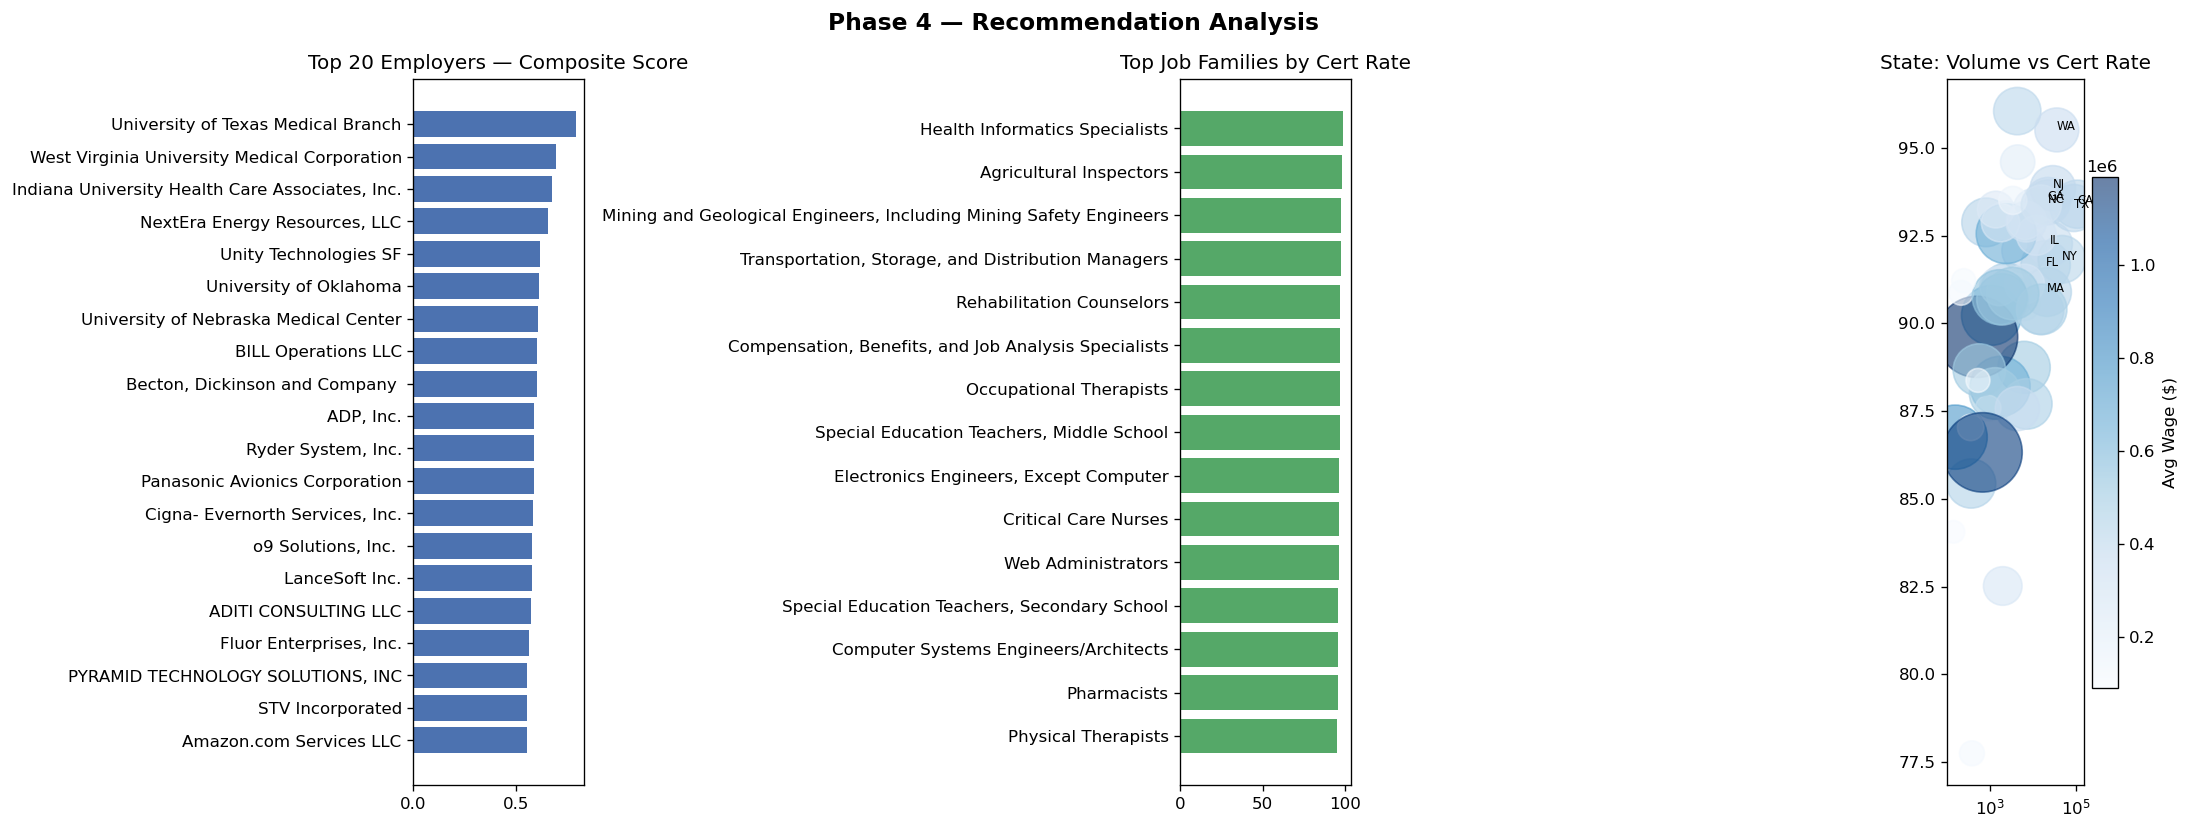

In [24]:
# Job family analysis
job_cert = (h1b.groupby('SOC_TITLE')
               .agg(cert_rate=('IS_CERTIFIED','mean'), count=('IS_CERTIFIED','count'))
               .query('count >= 100').nlargest(15,'cert_rate').reset_index())

# Geographic landscape
geo = (h1b.groupby('WORKSITE_STATE')
          .agg(cert_rate=('IS_CERTIFIED','mean'), avg_wage=('ANNUAL_WAGE','mean'), volume=('IS_CERTIFIED','count'))
          .query('volume >= 100').reset_index())

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('Phase 4 — Recommendation Analysis', fontsize=14, fontweight='bold')

axes[0].barh(top20['EMPLOYER_NAME'][::-1], top20['score'][::-1], color='#4C72B0')
axes[0].set_title('Top 20 Employers — Composite Score')

axes[1].barh(job_cert['SOC_TITLE'][::-1], (job_cert['cert_rate']*100)[::-1], color='#55A868')
axes[1].set_title('Top Job Families by Cert Rate')

sc = axes[2].scatter(geo['volume'], geo['cert_rate']*100, s=geo['avg_wage']/500,
                     alpha=0.6, c=geo['avg_wage'], cmap='Blues')
for _, r in geo.nlargest(10,'volume').iterrows():
    axes[2].annotate(r['WORKSITE_STATE'], (r['volume'], r['cert_rate']*100), fontsize=7)
axes[2].set_xscale('log'); axes[2].set_title('State: Volume vs Cert Rate')
plt.colorbar(sc, ax=axes[2], label='Avg Wage ($)')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/phase4_recommendation.png', bbox_inches='tight')
plt.show()

## Phase 5 — Executive Summary

In [25]:
best_employer   = top20.iloc[0]['EMPLOYER_NAME']
best_cert_state = geo.nlargest(1,'cert_rate').iloc[0]['WORKSITE_STATE']
best_wage_state = geo.nlargest(1,'avg_wage').iloc[0]['WORKSITE_STATE']

print('='*65)
print('  TOP 3 INSIGHTS')
print('='*65)
print(f'  1. Employers paying ≥125% prevailing wage have significantly higher cert rates.')
print(f'  2. Top employer "{best_employer}" leads composite score; product companies beat staffing firms.')
print(f'  3. State "{best_cert_state}" leads cert rate; "{best_wage_state}" leads in avg wages.')

print('\n' + '='*65)
print('  TOP 3 RISKS / LIMITATIONS')
print('='*65)
print('  1. LCA cert ≠ H-1B visa approval — USCIS lottery risk not in this data.')
print('  2. IT staffing firm data skews volume metrics with lower cert rates.')
print('  3. Wage normalisation assumes standard hours; part-time roles may be distorted.')

print('\n' + '='*65)
print('  ★  RECOMMENDATION TO CANDIDATE')
print('='*65)
print(f'  Target product-based tech companies like "{best_employer}" tier.')
print(f'  Apply for Software/Data/ML Engineer roles (SOC 15-1xxx).')
print(f'  Negotiate salary at PW Level III or IV.')
print(f'  Prefer worksite states: {best_cert_state}, CA, WA, TX.')
print(f'  Always go full-time; avoid amended petitions.')

  TOP 3 INSIGHTS
  1. Employers paying ≥125% prevailing wage have significantly higher cert rates.
  2. Top employer "University of Texas Medical Branch" leads composite score; product companies beat staffing firms.
  3. State "AR" leads cert rate; "ME" leads in avg wages.

  TOP 3 RISKS / LIMITATIONS
  1. LCA cert ≠ H-1B visa approval — USCIS lottery risk not in this data.
  2. IT staffing firm data skews volume metrics with lower cert rates.
  3. Wage normalisation assumes standard hours; part-time roles may be distorted.

  ★  RECOMMENDATION TO CANDIDATE
  Target product-based tech companies like "University of Texas Medical Branch" tier.
  Apply for Software/Data/ML Engineer roles (SOC 15-1xxx).
  Negotiate salary at PW Level III or IV.
  Prefer worksite states: AR, CA, WA, TX.
  Always go full-time; avoid amended petitions.
